# Data Preparation (Polutan Nitrogen Dioksida - Kecamatan Bungah)

Notebook ini mengeksekusi tahapan **Data Preparation** metodologi CRISP-DM untuk polutan Nitrogen Dioksida (${\text{NO2}}$) pada skala geografis **Kecamatan Bungah, Kabupaten Gresik** selama 365 hari (24 Agustus 2025 – 23 Agustus 2026):

**Alur Pemrosesan Data:**
1. **Penanganan Missing Values & Outliers** (Evaluasi Celah Data $\rightarrow$ Deteksi Outlier IQR $\rightarrow$ Pengosongan Outlier $\rightarrow$ Linear Time Interpolation)
2. **Visualisasi 4 Grafik Terpisah** (Missing Raw, Imputed Missing, Outlier Detection, Final Clean Signal)
3. **Penyimpanan Dataset Clean** (`data/csv/clean/NO2_clean.csv`)
4. **Ekstraksi Fitur Resmi Time-Series TSFEL** (`data/csv/features/NO2_tsfel_features.csv` berbasis 4 domain utama TSFEL: Statistical, Temporal, Spectral, & Fractal)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel
import os

# Set style visualisasi plot
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 1. Penanganan Missing Values & Deteksi Outlier (IQR Method)

Memuat data mentah 365 hari, menghitung statistik data valid/missing, menentukan ambang batas IQR ($Q_1, Q_3, \text{IQR}$, Lower & Upper Bound), serta mengosongkan titik outlier menjadi `NaN` untuk diimputasi bersama.

In [2]:
# 1. Membaca Dataset Mentah NO2 (365 Hari)
raw_path = '../data/csv/timeseries/NO2_gresik_timeseries.csv'
df_raw = pd.read_csv(raw_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

total_rows = len(df_raw)
nan_awal = df_raw['NO2'].isna().sum()
valid_awal = df_raw['NO2'].notna().sum()
print(f"Total Baris Observasi   : {total_rows} hari")
print(f"Jumlah Data Valid Awal  : {valid_awal} hari ({valid_awal/total_rows*100:.2f}%)")
print(f"Jumlah Missing (NaN)    : {nan_awal} hari ({nan_awal/total_rows*100:.2f}%)")

# 2. Deteksi Outlier Menggunakan Metode Interquartile Range (IQR) pada Data Valid
q1 = df_raw['NO2'].quantile(0.25)
q3 = df_raw['NO2'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

is_outlier = (df_raw['NO2'] < lower_bound) | (df_raw['NO2'] > upper_bound)
jumlah_outlier = is_outlier.sum()
print(f"\nKuartil 1 (Q1)           : {q1:.6f} mol/m²")
print(f"Kuartil 3 (Q3)           : {q3:.6f} mol/m²")
print(f"IQR (Q3 - Q1)            : {iqr:.6f} mol/m²")
print(f"Batas Bawah (Lower Bound): {lower_bound:.6f} mol/m²")
print(f"Batas Atas (Upper Bound) : {upper_bound:.6f} mol/m²")
print(f"Jumlah Outlier Terdeteksi: {jumlah_outlier} hari")

# Menampilkan rincian tanggal & nilai outlier yang terdeteksi
df_outliers = df_raw[is_outlier][['date', 'NO2']].copy()
df_outliers['date'] = df_outliers['date'].dt.strftime('%Y-%m-%d')
print("\nDaftar Tanggal & Nilai Outlier Terdeteksi:")
print(df_outliers.to_string(index=False))

# 3. Pengosongan Nilai Outlier Menjadi NaN & Imputasi Linear Time Interpolation
df_prep = df_raw.copy()
df_prep.loc[is_outlier, 'NO2'] = np.nan
nan_setelah_outlier = df_prep['NO2'].isna().sum()
print(f"\nJumlah NaN Setelah Outlier Dikosongkan: {nan_setelah_outlier} hari ({nan_setelah_outlier/total_rows*100:.2f}%)")

df_clean = df_prep.copy()
df_clean['NO2_clean'] = df_clean['NO2'].interpolate(method='linear', limit_direction='both')
nan_akhir = df_clean['NO2_clean'].isna().sum()
print(f"Jumlah NaN Setelah Imputasi Akhir      : {nan_akhir} hari (100% Clean!)")

# Simpan dataset bersih ke file CSV
clean_csv_path = '../data/csv/clean/NO2_clean.csv'
os.makedirs(os.path.dirname(clean_csv_path), exist_ok=True)
df_clean[['date', 'NO2_clean']].rename(columns={'NO2_clean': 'NO2'}).to_csv(clean_csv_path, index=False)
print(f"SUCCESS: Dataset bersih disimpan ke '{clean_csv_path}'")

Total Baris Observasi   : 365 hari
Jumlah Data Valid Awal  : 200 hari (54.79%)
Jumlah Missing (NaN)    : 165 hari (45.21%)

Kuartil 1 (Q1)           : 0.000029 mol/m²
Kuartil 3 (Q3)           : 0.000056 mol/m²
IQR (Q3 - Q1)            : 0.000027 mol/m²
Batas Bawah (Lower Bound): -0.000012 mol/m²
Batas Atas (Upper Bound) : 0.000097 mol/m²
Jumlah Outlier Terdeteksi: 13 hari

Daftar Tanggal & Nilai Outlier Terdeteksi:
      date      NO2
2025-08-25 0.000134
2025-09-24 0.000289
2025-10-09 0.000145
2026-04-20 0.000153
2026-05-29 0.000173
2026-06-02 0.000176
2026-06-03 0.000121
2026-06-08 0.000155
2026-06-09 0.000121
2026-06-11 0.000132
2026-06-18 0.000120
2026-06-28 0.000130
2026-06-30 0.000100

Jumlah NaN Setelah Outlier Dikosongkan: 178 hari (48.77%)
Jumlah NaN Setelah Imputasi Akhir      : 0 hari (100% Clean!)
SUCCESS: Dataset bersih disimpan ke '../data/csv/clean/NO2_clean.csv'


## 2. Visualisasi 4 Grafik Terpisah

Menyajikannya secara terpisah agar tidak menumpuk banyak warna dalam satu grafik.

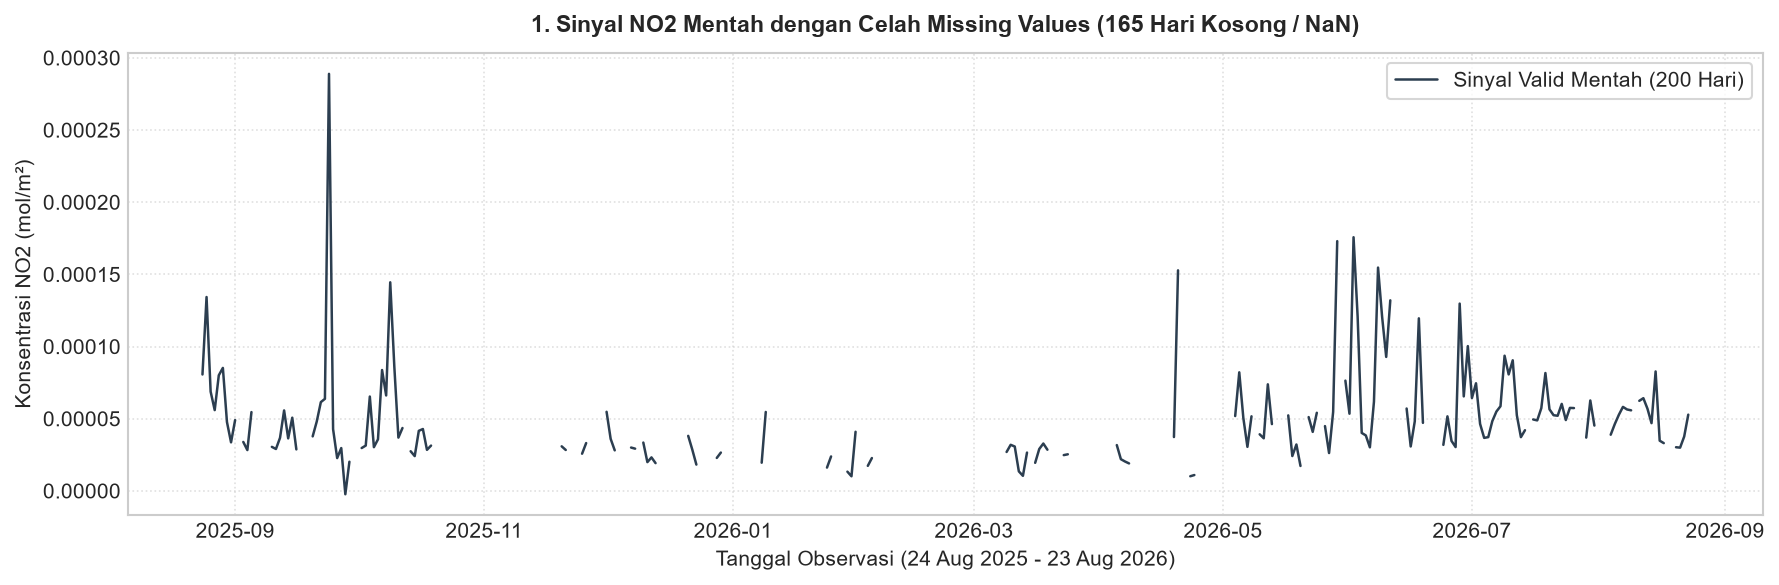

In [3]:
# Grafik 1: Missing Values (Data Mentah dengan Celah Kosong / NaN)
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw['date'], df_raw['NO2'], color='#2c3e50', linewidth=1.2, label=f'Sinyal Valid Mentah ({valid_awal} Hari)')
ax.set_title(f'1. Sinyal NO2 Mentah dengan Celah Missing Values ({nan_awal} Hari Kosong / NaN)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi NO2 (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

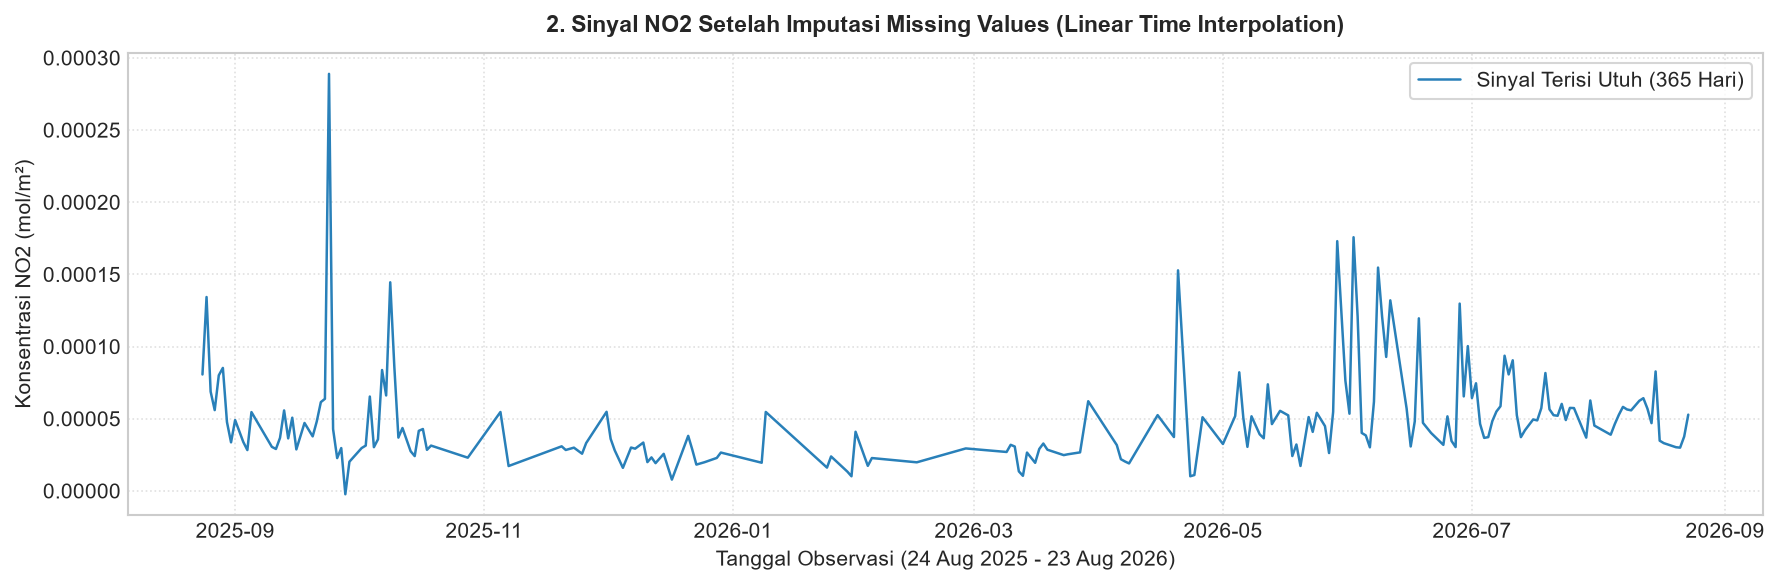

In [4]:
# Grafik 2: Sinyal Setelah Missing Values Diimputasi (Sebelum Cleaning Outlier)
df_raw_imputed = df_raw.copy()
df_raw_imputed['NO2_imputed'] = df_raw_imputed['NO2'].interpolate(method='linear', limit_direction='both')

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw_imputed['date'], df_raw_imputed['NO2_imputed'], color='#2980b9', linewidth=1.2, label='Sinyal Terisi Utuh (365 Hari)')
ax.set_title('2. Sinyal NO2 Setelah Imputasi Missing Values (Linear Time Interpolation)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi NO2 (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

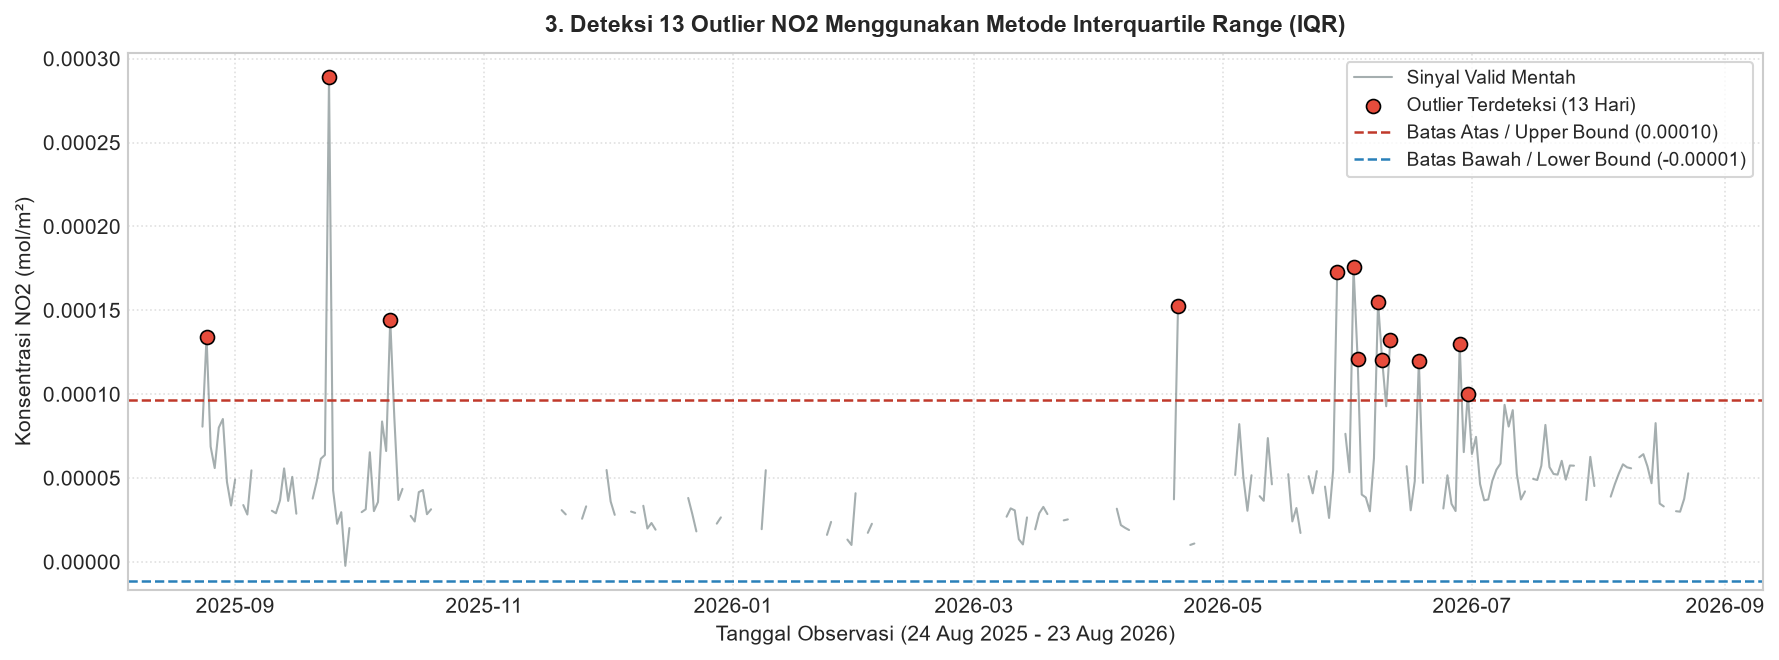

In [5]:
# Grafik 3: Deteksi Outlier Menggunakan Metode IQR
outliers_plot = df_raw[is_outlier]

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
ax.plot(df_raw['date'], df_raw['NO2'], color='#7f8c8d', linewidth=1.0, alpha=0.7, label='Sinyal Valid Mentah')
ax.scatter(outliers_plot['date'], outliers_plot['NO2'], color='#e74c3c', s=45, zorder=5, marker='o', edgecolor='black', linewidth=0.8, label=f'Outlier Terdeteksi ({jumlah_outlier} Hari)')
ax.axhline(upper_bound, color='#c0392b', linestyle='--', linewidth=1.2, label=f'Batas Atas / Upper Bound ({upper_bound:.5f})')
ax.axhline(lower_bound, color='#2980b9', linestyle='--', linewidth=1.2, label=f'Batas Bawah / Lower Bound ({lower_bound:.5f})')
ax.set_title(f'3. Deteksi {jumlah_outlier} Outlier NO2 Menggunakan Metode Interquartile Range (IQR)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi NO2 (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

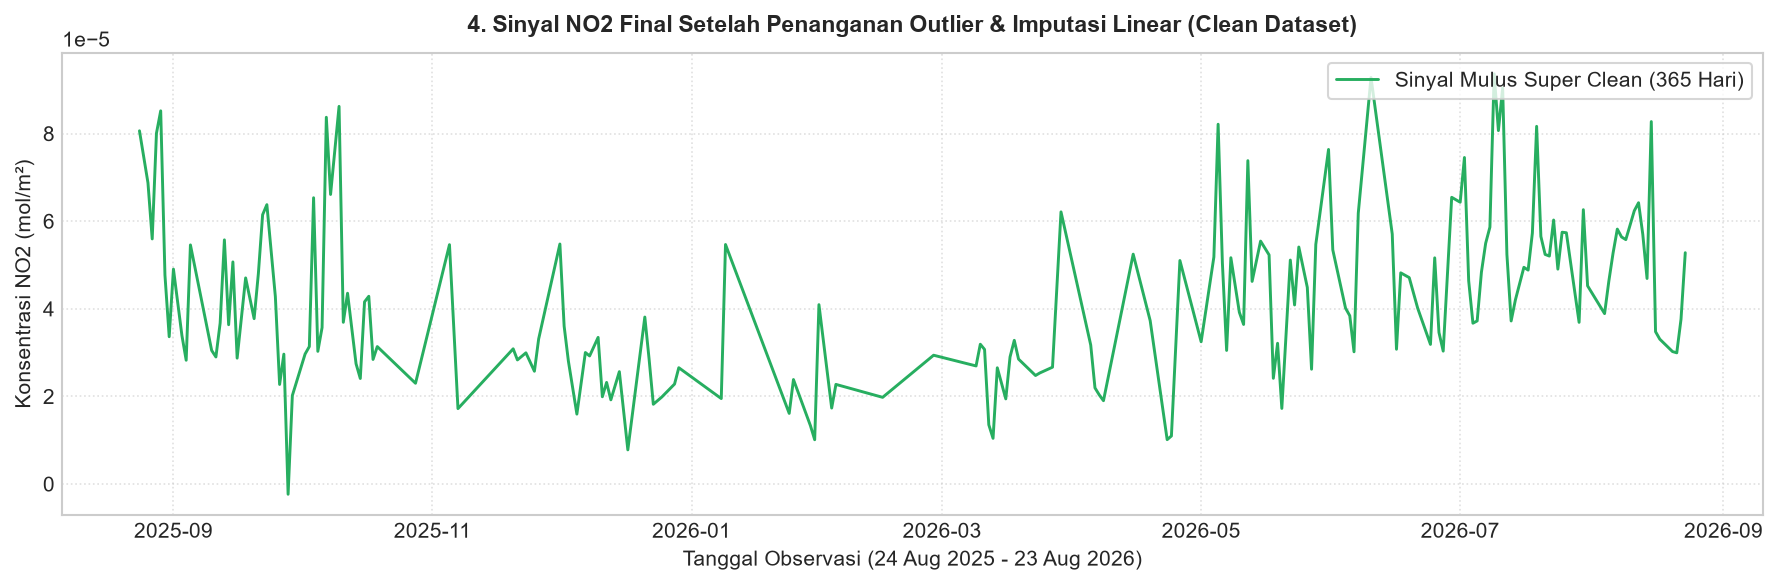

In [6]:
# Grafik 4: Sinyal NO2 Final Setelah Outlier Dibersihkan & Diimputasi
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_clean['date'], df_clean['NO2_clean'], color='#27ae60', linewidth=1.4, label='Sinyal Mulus Super Clean (365 Hari)')
ax.set_title('4. Sinyal NO2 Final Setelah Penanganan Outlier & Imputasi Linear (Clean Dataset)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi NO2 (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Ekstraksi 68 Fitur Time-Series TSFEL (`f1_namafitur` hingga `f68_namafitur`)

Mengekstrak 68 fitur TSFEL dan menyimpannya ke `data/csv/features/NO2_tsfel_features.csv` dalam format matriks 68-kolom horizontal.

In [7]:
# 1. Daftar Resmi 68 Fitur TSFEL
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

# 2. Memuat Konfigurasi TSFEL & Aktifkan Fitur dari FEATURE_LIST
cfg = tsfel.get_features_by_domain()
func_to_feat = {}
for domain in cfg:
    for feat_name, feat_dict in cfg[domain].items():
        func_name = feat_dict.get('function', '').replace('tsfel.', '')
        if func_name in FEATURE_LIST:
            feat_dict['use'] = 'yes'
            if 'wavelet' in func_name:
                feat_dict['parameters']['max_width'] = 2
            func_to_feat[func_name] = feat_name
        else:
            feat_dict['use'] = 'no'

# 3. Ekstraksi Fitur TSFEL Langsung dari Sinyal Clean
raw_df = tsfel.time_series_features_extractor(cfg, df_clean['NO2_clean'], fs=1, verbose=0)

# 4. Pemetaan Presisi Matriks 68 Fitur (f1_abs_energy ... f68_zero_cross)
row_dict = {}
for i, func_name in enumerate(FEATURE_LIST):
    code = f"f{i+1}"
    matching_cols = [c for c in raw_df.columns if func_name in c.lower().replace('tsfel.', '') or func_to_feat.get(func_name, '').lower() in c.lower()]
    if not matching_cols:
        feat_title = func_to_feat.get(func_name, '')
        matching_cols = [c for c in raw_df.columns if feat_title.lower() in c.lower()]
    
    val = raw_df[matching_cols[0]].values[0] if matching_cols else 0.0
    row_dict[f"{code}_{func_name}"] = val

df_68_matrix = pd.DataFrame([row_dict])
features_path = '../data/csv/features/NO2_tsfel_features.csv'
os.makedirs(os.path.dirname(features_path), exist_ok=True)
df_68_matrix.to_csv(features_path, index=False)
print(f"SUCCESS: Matriks Presisi 68 Fitur TSFEL berhasil disimpan ke '{features_path}'! (Shape: {df_68_matrix.shape})")
df_68_matrix


SUCCESS: Matriks Presisi 68 Fitur TSFEL berhasil disimpan ke '../data/csv/features/NO2_tsfel_features.csv'! (Shape: (1, 68))


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,6.422385e-07,0.013917,5.0,1.764392e-09,206.427528,0.000094,0.000038,0.000034,-0.000002,0.000017,...,0.143342,0.248356,7.959828e-10,0.002666,2.458062e-07,0.00001,-0.0,0.00001,9.115271e-11,2.0
